<a href="https://colab.research.google.com/github/baynobu/244107020232-mobile-course/blob/main/PCVK_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRAKTIKUM**

 **D1. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna
pada OpenCV dan konversinya**

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from skimage import io
from google.colab.patches import cv2_imshow

1. Membuat koneksi antara Colab dengan Google Drive agar bisa
mengakses file di dalamnya.

In [12]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Menampilkan Gambar

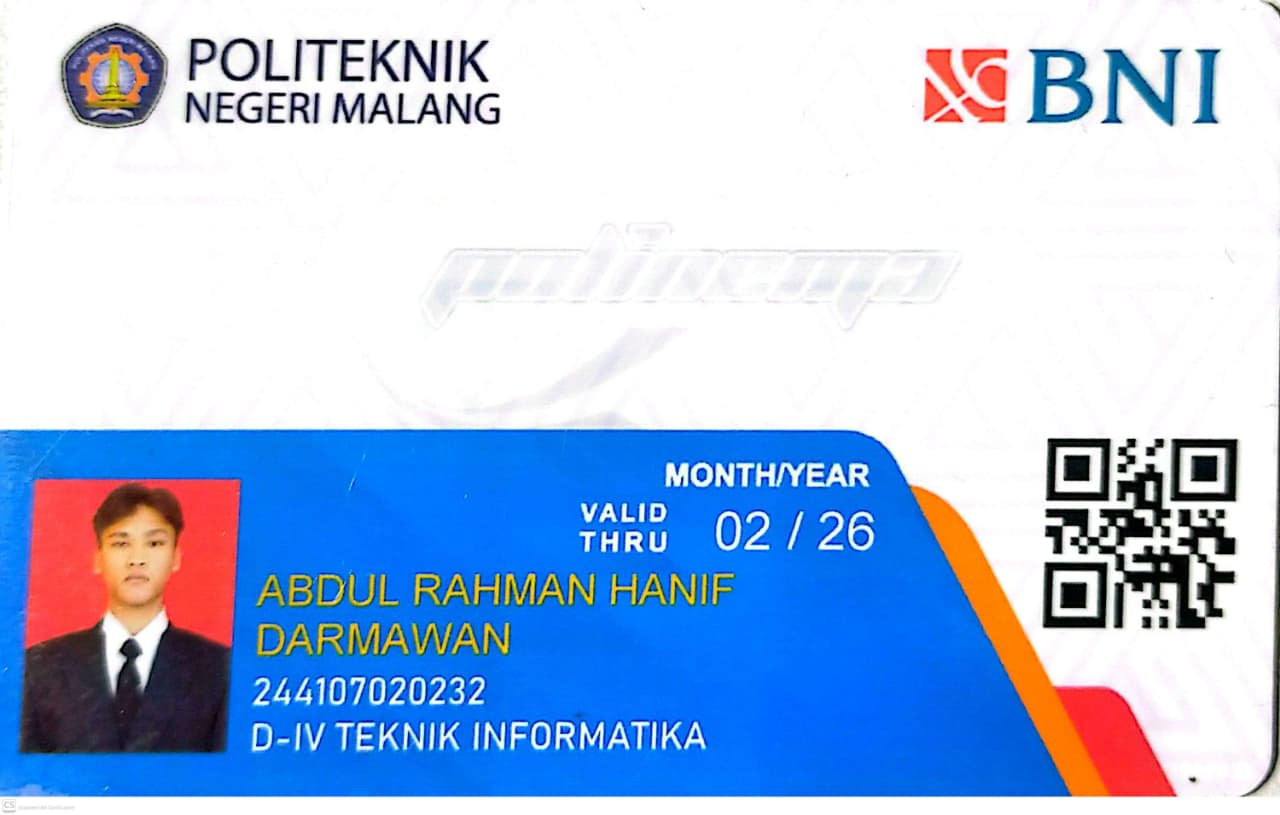

Resolusi Gambar:  1280  x  815



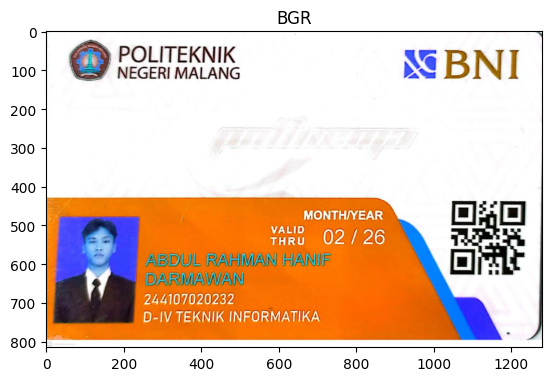

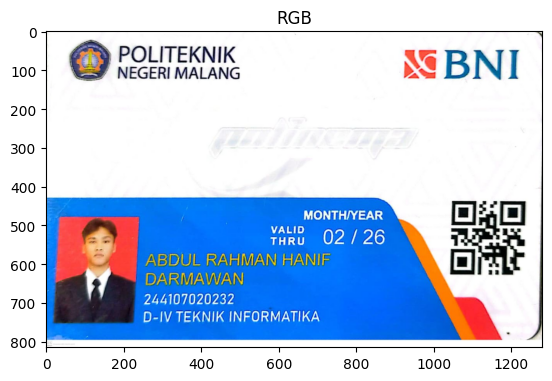

In [13]:
img = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg')

# OpenCV
cv2_imshow(img)
print("Resolusi Gambar: ",img.shape[1], " x ", img.shape[0])
print()

# format warna BGR
plt.imshow(img)
plt.title("BGR")
plt.show()

#konversi chanel BGR ke RGB
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.title("RGB")
plt.imshow(img2)
plt.show()


3. Menampilkan Citra Grayscale

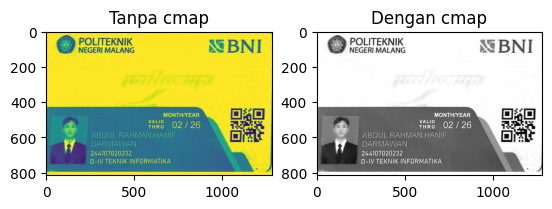

In [18]:
im_gray = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(im_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(im_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

4. Melakukan resizing

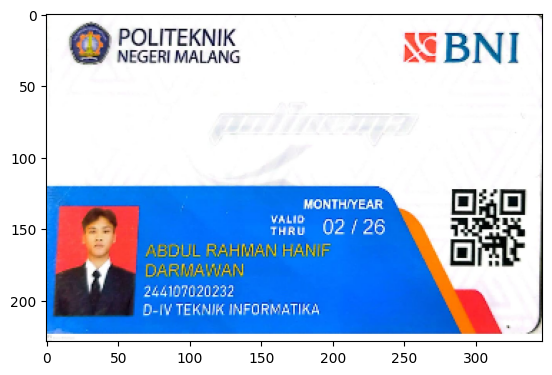

In [19]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB,(347,229))
plt.imshow(img_output)


5. Melakukan Flipping

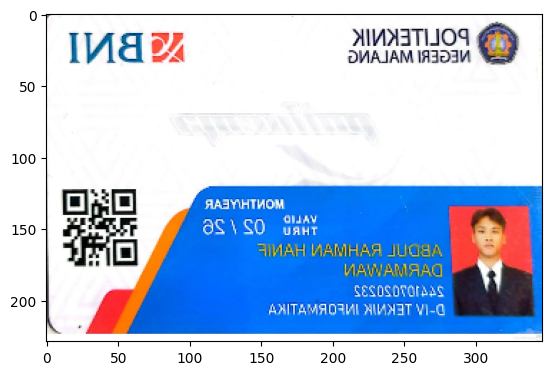

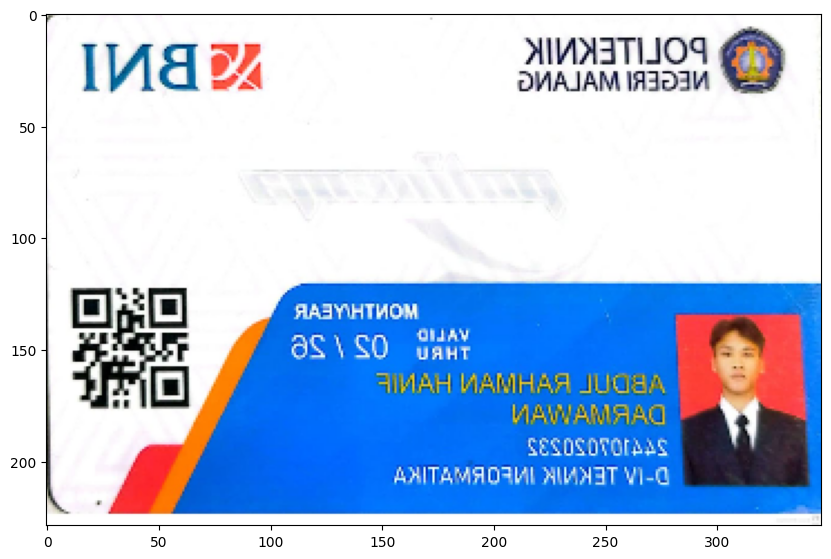

In [20]:
imgFlip = cv.flip(img_output, 1)
plt.imshow(imgFlip)

# Tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)


6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan
black image dengan tipe data int16.

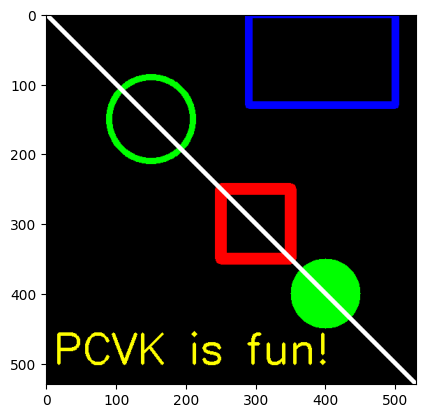

In [ ]:
black_img = np.zeros(shape=(530,530,3),dtype=np.int16)

#Menambahkan bentuk persegi panjang
cv.rectangle(black_img,pt1=(290,0),pt2=(500,130),color=(0,0,255),thickness=10)

#Menambahkan bentuk persegi
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)

#Menambahkan bentuk lingkaran
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)

#Menambahkan lingkaran berwarna
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)

#Menambahkan Garis
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)

#Menambahkan text
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
           color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

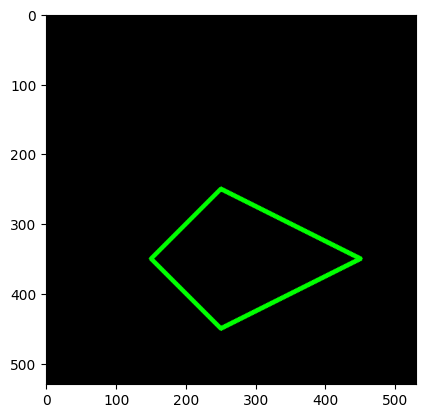

In [ ]:
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)

vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

pts = vertices.reshape((-1,1,2))
pts

cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)


# **PERTANYAAN PRAKTIKUM**

**1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.**

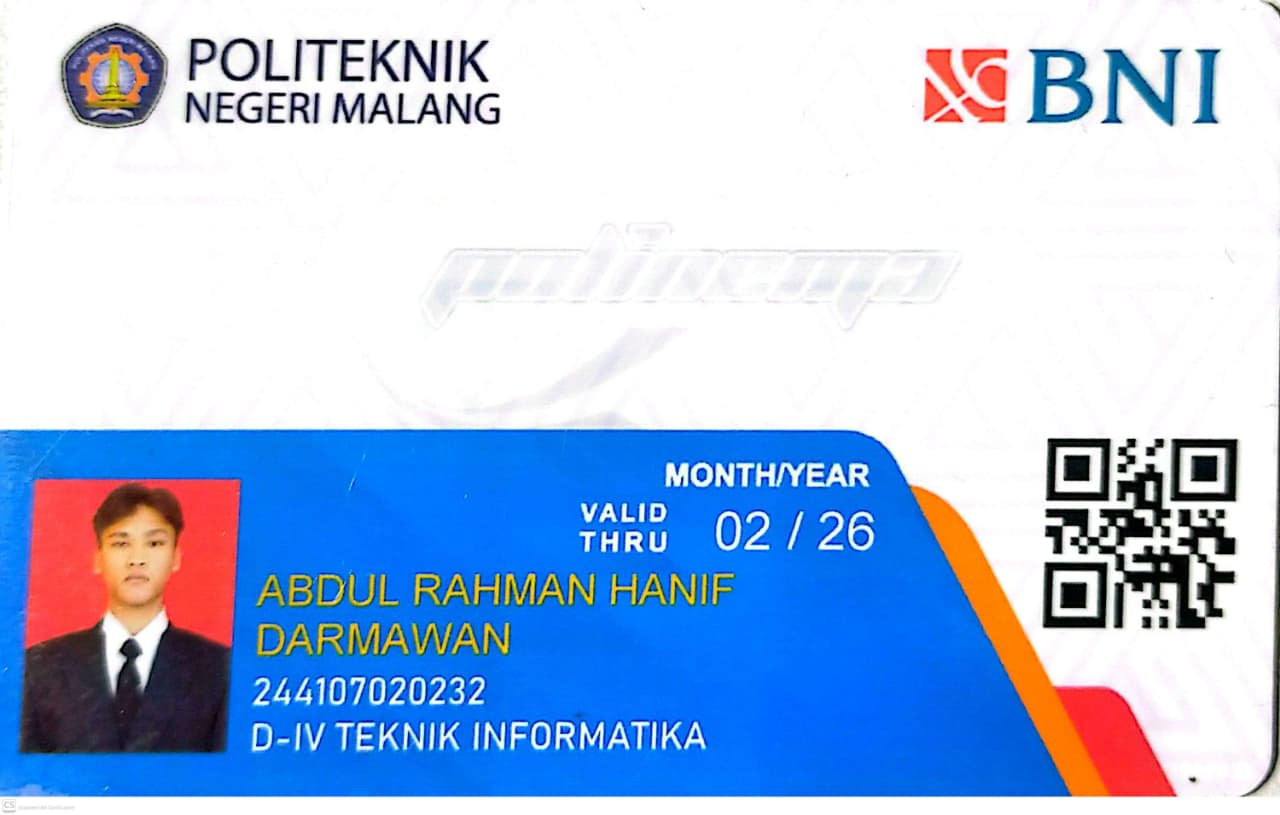

Nilai piksel [100,100] = [ 13 103 144]


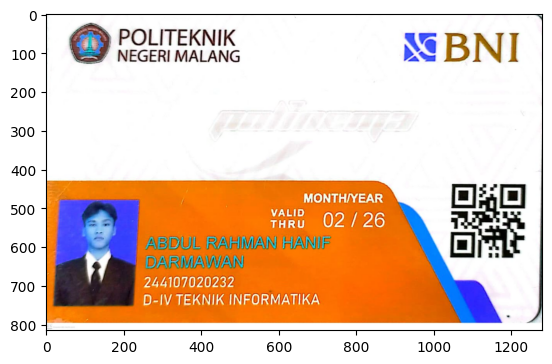

In [21]:
cv2_imshow(img)

plt.imshow(img)


print("Nilai piksel [100,100] =", img[100,100])

Hasil tampilan cv2_imshow() dan plt.imshow() berbeda karena OpenCV membaca citra dalam format BGR (Blue, Green, Red), sedangkan Matplotlib menampilkan citra dalam format RGB (Red, Green, Blue). Akibatnya kanal merah dan biru tertukar ketika citra OpenCV ditampilkan langsung menggunakan plt.imshow() tanpa konversi warna. Buktinya yaitu, nilai pixel pada kode program tetap sama yaitu [191 188 183], tetapi OpenCV membacanya sebagai Blue = 191, Green= 188, Red = 183. Sedangkan Matplotlib membacanya sebagai Red = 191, Green = 188, Blue = 183. Inilah yang membuat warna yag ditampilkan berbeda

**2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.**

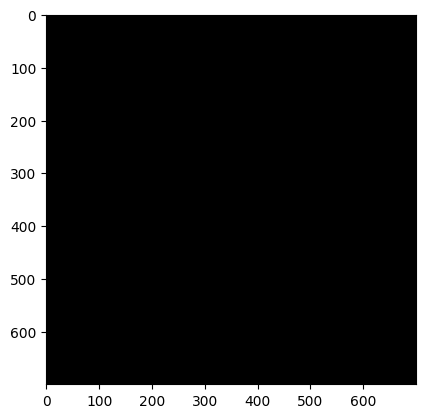

INT16
dtype : int16
min   : 0
max   : 0
nbytes: 2940000



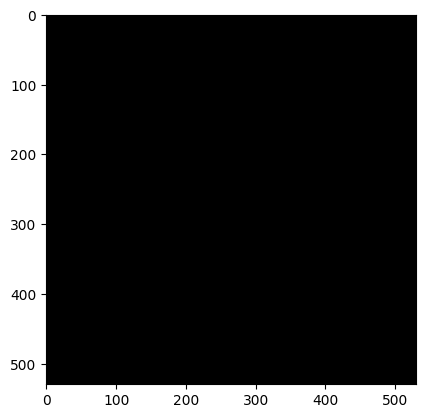

INT32
dtype : int32
min   : 0
max   : 0
nbytes: 3370800


In [44]:
canvas16 = np.zeros((700,700,3), dtype=np.int16)
plt.imshow(canvas16)
plt.show()

print("INT16")
print("dtype :", canvas16.dtype)
print("min   :", canvas16.min())
print("max   :", canvas16.max())
print("nbytes:", canvas16.nbytes)

print()

canvas32 = np.zeros((530,530,3), dtype=np.int32)
plt.imshow(canvas32)
plt.show()

print("INT32")
print("dtype :", canvas32.dtype)
print("min   :", canvas32.min())
print("max   :", canvas32.max())
print("nbytes:", canvas32.nbytes)

Kedua kanvas memiliki tampilan yang sama karena seluruh piksel bernilai 0 sehingga keduanya berwarna hitam. yang membedakan adalah nilai dtypenya. Int16 menggunakan 2 byte per elemen, sedangkan int 32 menggunakan 4 byte per elemen. Akibatnya ukuran nbytes dari kanvas int32 menjadi dua kali lebih besar dari kanvas int16. Jadi walupun hasilnya sama, kebutuhan memorinya berbeda karena jumlah byte yang digunakan untuk menyimpan setiap pixel berbeda

**3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?**

Baris tersebut berfungsi untuk mengimpor fungsi cv2_imshow() yang digunakankan untuk menampilkan cita OpenCV di Google colab. Fungsi cv2.imshow() bawaan OpenCV tidak dapat digunakan di Google Colab karena membutuhkan GUI dan jendela sistem operasi untuk menampilkan gambar. Google Colab berjalan di server cloud dan tidak memiliki akses ke jendela GUI tersebut. Oleh karena itu Google Colab menyediakan fungsi pengganti yaitu cv2_imshow() yang dapat menampilkan citra langsung di dalam notebook.

**4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.**

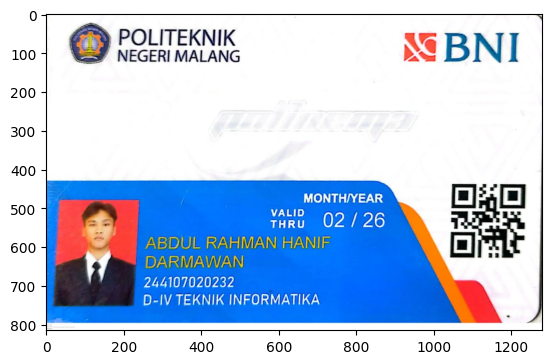

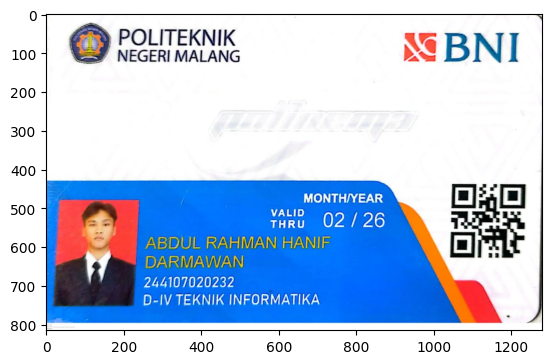

Nilai piksel [100,100] =
skimage : [144 103  13]
OpenCV RGB : [144 103  13]


In [26]:
img_sk = io.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg')
plt.imshow(img_sk)
plt.show()

img_cv = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg')
img_rgb = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

print("Nilai piksel [100,100] =")

print("skimage :", img_sk[100,100])
print("OpenCV RGB :", img_rgb[100,100])

Citra yang dibaca menggunakan skimage.io.imread() sudah menggunakan format RGB, sedangkan citra yang dibaca dengan OpenCV perlu dikonversi terlebih dahulu menggunakan cv.cvtColor(img, cv.COLOR_BGR2RGB) agar menjadi RGB. Dari hasil nilai piksel yang diperoleh, kedua citra memiliki nilai yang sama, sehingga dapat disimpulkan bahwa keduanya menampilkan warna yang sebenarnya. Pertukaran kanal warna hanya terjadi jika citra hasil cv.imread() langsung ditampilkan dengan plt.imshow() tanpa dilakukan konversi dari BGR ke RGB terlebih dahulu.

**5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.**

Shape sebelum = (815, 1280, 3)


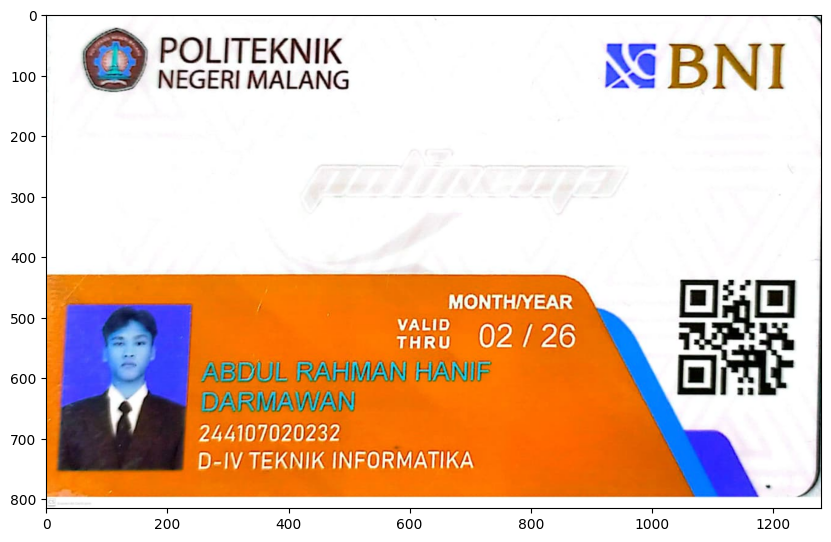

Shape sesudah = (815, 1280, 3)


In [27]:
print("Shape sebelum =", img.shape)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

print("Shape sesudah =", img.shape)

Nilai img.shape tidak berubah meskipun gambar ditampilkan dengan figsize yang lebih besar. Hal ini karena figsize hanya mengubah ukuran tampilan gambar di layar, bukan ukuran citra sebenarnya. Jika ingin mengubah ukuran citra, harus menggunakan fungsi cv.resize(), karena fungsi tersebut akan mengubah jumlah piksel dan nilai img.shape. Jadi, figsize hanya memengaruhi tampilan, sedangkan cv.resize() mengubah ukuran citra yang sebenarnya.

# **TUGAS PRAKTIKUM - PENERAPAN**

**1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.**

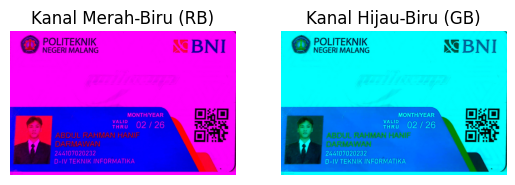

In [28]:
img = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#Menyalin Gambar
rb = img_rgb.copy()
gb = img_rgb.copy()

#RB, Green = 0
rb[:,:,1] = 0

# GB, Red = 0
gb[:,:,0] = 0

plt.subplot(1,2,1)
plt.imshow(rb)
plt.title('Kanal Merah-Biru (RB)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gb)
plt.title('Kanal Hijau-Biru (GB)')
plt.axis('off')

plt.show()

**2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.**

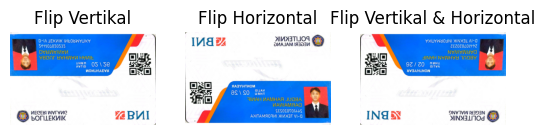

In [29]:
flip_vertikal = cv.flip(img_rgb, 0)
flip_horizontal = cv.flip(img_rgb, 1)
flip_keduanya = cv.flip(img_rgb, -1)

plt.subplot(1,3,1)
plt.imshow(flip_vertikal)
plt.title('Flip Vertikal')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(flip_horizontal)
plt.title('Flip Horizontal')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(flip_keduanya)
plt.title('Flip Vertikal & Horizontal')
plt.axis('off')

plt.show()

**3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /
badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.**

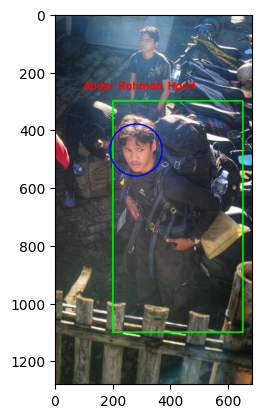

In [39]:
img_aktivitas = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/aktivitas.jpeg')
img_rgb = cv.cvtColor(img_aktivitas, cv.COLOR_BGR2RGB)

# Rectangle pada badan (x1, y1) hingga (x2, y2)
cv.rectangle(img_rgb, pt1=(200, 300), pt2=(650, 1100), color=(0, 255, 0), thickness=3)

# Circle pada wajah (center_x, center_y), radius
cv.circle(img_rgb, center=(280, 470), radius=90, color=(0, 0, 255), thickness=3)

# Menambahkan teks nama di atas kepala
cv.putText(img_rgb, text='Abdul Rahman Hanif', org=(100, 260), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=1.2, color=(255, 0, 0), thickness=3)

plt.imshow(img_rgb)

# **TUGAS PRAKTIKUM - ANALISA**

**Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.**

Apakah proses konversi citra RGB menjadi grayscale mengubah rata-rata intensitas piksel pada gambar?

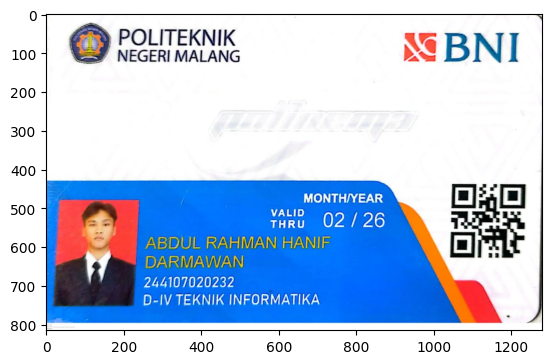

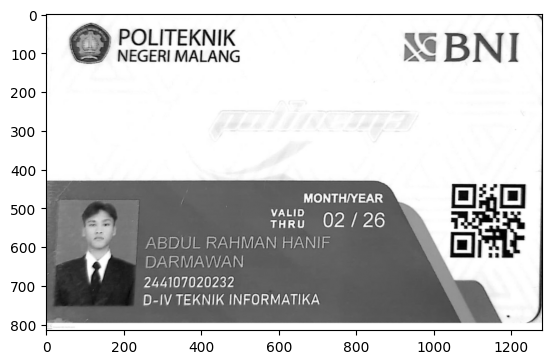

Rata-rata intensitas RGB : 195.6442583716769
Rata-rata intensitas Grayscale : 189.196987154908


In [40]:
img = cv.imread('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM/KTM.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()


# Konversi RGB ke Grayscale
img_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.show()


# Menghitung rata-rata intensitas
mean_rgb = np.mean(img_rgb)
mean_gray = np.mean(img_gray)

print("Rata-rata intensitas RGB :", mean_rgb)
print("Rata-rata intensitas Grayscale :", mean_gray)

Berdasarkan hasil percobaan, intensitas antara gambar RGB dan greyscale berbeda, hal ini karena gambar greyscale memiliki satu kanal warna yaitu tingkat keabuan, sedangkan gambar RGB memiliki tiga kanal yaitu merah hijau dan biru. Meskipun begitu, perbedaannya nilainya tidak terlalu jauh, sehingga kecerahan gambar masih terlihat sama.

# **TUGAS PRAKTIKUM - APLIKASI**

**Studi Kasus 1**

Saving img1.jpg to img1.jpg


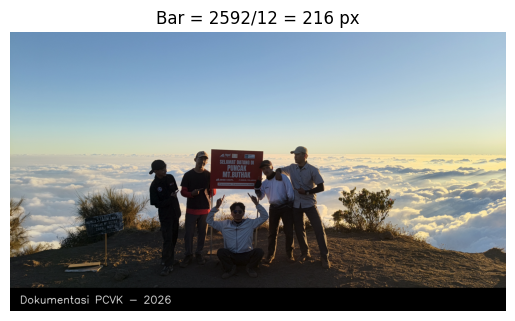

In [41]:
from google.colab import files
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Baca gambar
img_studikasus1 = cv.imread(filename)
img_rgb_studikasus1 = cv.cvtColor(img_studikasus1, cv.COLOR_BGR2RGB)

output = img_rgb_studikasus1.copy()

# Ukuran gambar
h, w = output.shape[:2]

# Tinngi bar yaitu 1/12 dari tinggi gambar
bar_h = h // 12


# Menggambar bar hitam di bawah
cv.rectangle( output, pt1=(0, h-bar_h), pt2=(w, h), color=(0,0,0), thickness=-1)

# Ukuran font adaptif
font_scale = h / 800

# Ketebalan huruf adaptif
thickness = max(1, h // 400)

# Menambahkan teks
cv.putText(output, text='Dokumentasi PCVK - 2026', org=(w//50, h - bar_h//3), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=font_scale, color=(255,255,255), thickness=thickness)

# Menampilkan hasil
plt.imshow(output)
plt.title(f'Bar = {h}/{12} = {bar_h} px')
plt.axis('off')
plt.show()

**Studi Kasus 2**

Saving shoes.jpg to shoes (1).jpg


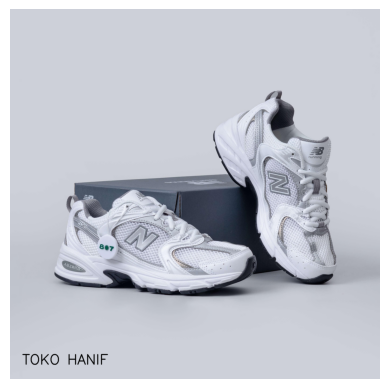

In [43]:
from google.colab import files
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Baca gambar
img_studikasus2 = cv.imread(filename)
img_rgb_studikasus2 = cv.cvtColor(img_studikasus2, cv.COLOR_BGR2RGB)

output = img_rgb_studikasus2.copy()

# Ukuran gambar asli
h2, w2 = output.shape[:2]

# Menentukan ukuran kanvas persegi
canvas_size = max(h2, w2)

# Membuat kanvas warna abu-abu muda
canvas = np.full((canvas_size, canvas_size, 3),220,dtype=np.int16)

# Menghitung posisi tengah
x = (canvas_size - w2) // 2
y = (canvas_size - h2) // 2

# Menempelkan gambar ke tengah kanvas
canvas[ y:y+h2, x:x+w2] = output


# Ukuran font adaptif
font_scale = canvas_size / 800

# Ketebalan huruf adaptif
thickness = max(1, h2 // 400)

# Menambahkan nama toko
cv.putText(canvas, text='TOKO HANIF', org=(canvas_size//30, canvas_size-canvas_size//25), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=font_scale, color=(0,0,0), thickness=thickness)

# Menampilkan hasil

plt.imshow(canvas)
plt.axis('off')
plt.show()